In [3]:
import os
import uproot

import numpy as np
import pandas as pd

from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Process the trigggers (.root) and glitches (.csv) and save as .csv

In [ ]:
folder = "/home/esanches/Projetos/tSNE/Virgo/zomicron"
exit_csv = "/home/esanches/Projetos/tSNE/Virgo/triggers_total.csv"

files = [f for f in os.listdir(folder) if f.endswith(".root")]

first = True

for arq in files:
    print(f"Reading: {arq}")
    caminho = os.path.join(folder, arq)
    
    with uproot.open(caminho) as f:
        tree = f["triggers;1"]
        df = tree.arrays(["time", "frequency", "snr"], library="pd")
        
    df.to_csv(exit_csv, mode="w" if first else "a", header=first, index=False)

    first = False
    del df

and the glitches .csv arquives

In [ ]:
pasta = "/home/esanches/Projetos/tSNE/Virgo/our_clustering"
files = glob.glob(os.path.join(pasta, "Clustered_*.csv"))

saida_csv = "/home/esanches/Projetos/tSNE/Virgo/gdchar.csv"
first = True   # write the header only one time

for f in files:
    print(f"Reading: {f}")
    
    df = pd.read_csv(f, header=0)
    df.to_csv(saida_csv, mode='w' if first else 'a', header=first, index=False)
    
    first = False
    del df

## Read and apply filters to triggers and glitches

In [70]:
tperc = 0.6
gperc = 1.0
trigg_size = 359385802
glit_size = 80399   
trigcols = ['time', 'frequency', 'snr']
glitcols = ['GPStime', 'centralFreq', 'snr', 'label', 'confidence']

In [71]:
ntrig, nglit = int(trigg_size*tperc), int(glit_size*gperc)
path = '/home/esanches/Projetos/tSNE/Virgo/'

In [72]:
np.random.seed(42)
skip_logic = lambda i: i > 0 and np.random.random() > tperc

In [73]:
trigg = pd.read_csv(path + "triggers_total.csv", skiprows=skip_logic, usecols=trigcols)
trigg = trigg.sort_values('time').reset_index(drop=True)

unclustered = trigg.copy()

In [74]:
unclustered

,time,frequency,snr
0,1.238165e+09,1421.921349,5.009650
1,1.238165e+09,1013.443826,5.133190
2,1.238165e+09,396.149524,5.281003
3,1.238165e+09,388.226028,5.152806
4,1.238165e+09,388.226028,5.112306
...,...,...,...
215639686,1.269672e+09,474.735572,55.750837
215639687,1.269672e+09,1031.195870,10.237396
215639688,1.269672e+09,716.005295,25.806371
215639689,1.269672e+09,879.323062,19.674751


In [75]:
glit = pd.read_csv(path + 'gspy.csv', usecols=glitcols)

In [76]:
glit = glit.drop(glit[glit['label'].isin(['None_of_the_Above', 'No_Glitch'])].index)
glit = glit[glit['confidence'] >= 0.9]
top10 = glit['label'].value_counts().head(10).index
glit = glit[glit['label'].isin(top10)].copy()

In [77]:
glit = glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)

Filter of 1000 glitches per label:

In [ ]:
limited_glit = glit.groupby('label', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42))

limited_glit = limited_glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)
clustered = limited_glit.copy()

Without filter:

In [78]:
nofilter_glit = glit.copy()
nofilter_glit = nofilter_glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)
clustered = nofilter_glit.copy()

In [79]:
clustered

,GPStime,snr,centralFreq,confidence,label
0,1.238166e+09,12.088,211.877,1.000,Blip
1,1.238167e+09,7.867,20.195,0.998,Low_Frequency_Lines
2,1.238167e+09,8.180,65.530,1.000,Blip
3,1.238167e+09,8.306,19.370,0.965,Low_Frequency_Lines
4,1.238168e+09,12.113,357.194,1.000,Whistle
...,...,...,...,...,...
40294,1.253974e+09,10.982,36.338,1.000,Scattered_Light
40295,1.253974e+09,12.798,592.631,1.000,Scattered_Light
40296,1.253974e+09,9.501,26.590,0.996,Low_Frequency_Burst
40297,1.253975e+09,7.619,3909.822,0.991,Low_Frequency_Lines


## Create glitchgrams

In [22]:
def glitch_to_glitchgram(unclustered, clustered, deltat, 
                         fmin=3, fmax=8192, tbins=41, fbins=30):
    """
    This function create one glitchgram from unclustered Omicron data, for each glitch.

    Parameters:
        df_triggers (dataFrame): A dataFrame of GPStimes of all triggers inside of some window.
        tmin, tmax (numbers): limits of GPStimes that contain all triggers of some glitch.
        fmin, fmax (numbers): frequency range for the glitchgram.
        n_time_bins (int): number of time bins.
        n_freq_bins (int): number of frequency bins.
        norm (boolean): True if you need normalize SNR values.

    Returns:
        array for some glitch: each entry is a SNR value from flattened (binsf × binst) matrix.
    """

    times_all = unclustered['time'].values
    freqs_all = unclustered['frequency'].values
    snrs_all  = unclustered['snr'].values

    vecs = []
    labs = []
    GPSs = []

    time_edges = np.linspace(-deltat/2, deltat/2, tbins+1)
    freq_edges = np.logspace(np.log10(fmin), np.log10(fmax), fbins+1)
    
    for i, row in enumerate(clustered.itertuples(index=False)):

        #t_center = getattr(row, 'GPStime')
        t_center = row.GPStime
    
        tmin = t_center - deltat/2
        tmax = t_center + deltat/2
    
        i0 = np.searchsorted(times_all, tmin, side="left")
        i1 = np.searchsorted(times_all, tmax, side="right")
    
        times = times_all[i0:i1] - t_center
        freqs = freqs_all[i0:i1]
        snrs  = snrs_all[i0:i1]

        if len(times) < 10: # Equivalente ao tcut
            continue
    
        df_triggers = pd.DataFrame({'time': times,'frequency': freqs,'snr': snrs})
        
        t_idx = np.digitize(df_triggers['time'].values, time_edges) - 1
        f_idx = np.digitize(df_triggers['frequency'].values, freq_edges) - 1
            
        # initial empty matrix
        A = np.zeros((fbins, tbins), dtype=float)
    
        for ti, fi, si in zip(t_idx, f_idx, snrs):
            if 0 <= ti < tbins and 0 <= fi < fbins:
                if si > A[fi, ti]:
                    A[fi, ti] = si
                    
        '''# normalização do SNR 
        if len(snrs) > 0:
            snr_min = snrs.min()
            snr_max = snrs.max()
            if snr_max > snr_min:
                norm_snrs = (snrs - snr_min) / (snr_max - snr_min)
            else:
                norm_snrs = np.zeros_like(snrs)
        else:
            norm_snrs = snrs'''
        
        vecs.append(A.flatten(order="C"))
        labs.append(clustered['label'][i])
        GPSs.append(clustered['GPStime'][i])

    vecs_final = np.array(vecs).astype('float32')
    labs_final = np.array(labs)
    GPSs_final = np.array(GPSs).astype('float32')
    
    savepath = '/home/esanches/Projetos/tSNE/Virgo/teste1/'
    np.save(savepath + 'vecs_gspy.npy', vecs_final)
    np.save(savepath + 'labs_gspy.npy', labs_final)
    np.save(savepath + 'GPSs_gspy.npy', GPSs_final)
    
    return vecs_final, labs_final, GPSs_final

In [23]:
vecs, labs, GPSs = glitch_to_glitchgram(unclustered, clustered, deltat=1, fmin=3, fmax=8192, tbins=41, fbins=30)

## tSNE results

In [5]:
savepath = '/home/esanches/Projetos/tSNE/Virgo/VecsRepository/all_o3a_run/'

final_vecs = np.load(savepath + 'vecs_gspy.npy')
final_labs = np.load(savepath + 'labs_gspy.npy')
final_GPSs = np.load(savepath + 'GPSs_gspy.npy')

In [6]:
tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=30, learning_rate=200, 
            max_iter=1000, metric="euclidean", random_state=0)

proj = tsne.fit_transform(final_vecs)
proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])

In [7]:
labs = pd.DataFrame(final_labs).rename(columns={0 : 'vecs'})
GPSs = pd.DataFrame(final_GPSs).rename(columns={0 : 'GPSs'})

In [11]:
o3a_intervals = {
    'Abril':    (1238166018, 1240761618),  # 01/Apr/2019 15:00:00 UTC até 31/Apr (01/May 00:00:00 UTC)
    'Maio':     (1240761618, 1243440018),  # 01/May até 01/Jun
    'Junho':    (1243440018, 1246032018),  # 01/Jun até 01/Jul
    'Julho':    (1243440018, 1248710418),  # 01/Jul até 01/Aug
    'Agosto':   (1248710418, 1251388818),  # 01/Aug até 01/Sep
    'Setembro': (1251388818, 1253980818)   # 01/Sep até 01/Oct (Fim oficial do O3a)
}
gps_1d = GPSs.copy()

In [13]:
import pandas as pd
import os

save_path = '/home/esanches/Projetos/tSNE/Virgo/VecsRepository/all_o3a_run/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

traducao_meses = {
    'Abril': 'apr', 'Maio': 'may', 'Junho': 'jun', 
    'Julho': 'jul', 'Agosto': 'aug', 'Setembro': 'sep'
}

proj_np = proj_df.values if isinstance(proj_df, pd.DataFrame) else proj_df
gps_1d = np.array(GPSs).ravel()
labs = np.array(labs).ravel()
GPSs = np.array(GPSs).ravel()

for mes_pt, (t_start, t_end) in o3a_intervals.items():
    nome_abreviado = traducao_meses.get(mes_pt, mes_pt.lower())
    
    mask = (gps_1d >= t_start) & (gps_1d < t_end)
    
    if np.any(mask):
        df_proj_mes = pd.DataFrame(proj_np[mask], columns=['tsne_1', 'tsne_2'])
        
        df_proj_mes['label'] = labs[mask]
        df_proj_mes['GPStime'] = GPSs[mask]
        
        filename = f"proj_{nome_abreviado}.csv"
        df_proj_mes.to_csv(os.path.join(save_path, filename), index=False)
        
        print(f"Salvo: {filename} - {len(df_proj_mes)} projeções.")

Salvo: proj_apr.csv - 8522 projeções.
Salvo: proj_may.csv - 4047 projeções.
Salvo: proj_jun.csv - 2091 projeções.
Salvo: proj_jul.csv - 7125 projeções.
Salvo: proj_aug.csv - 5147 projeções.
Salvo: proj_sep.csv - 10670 projeções.


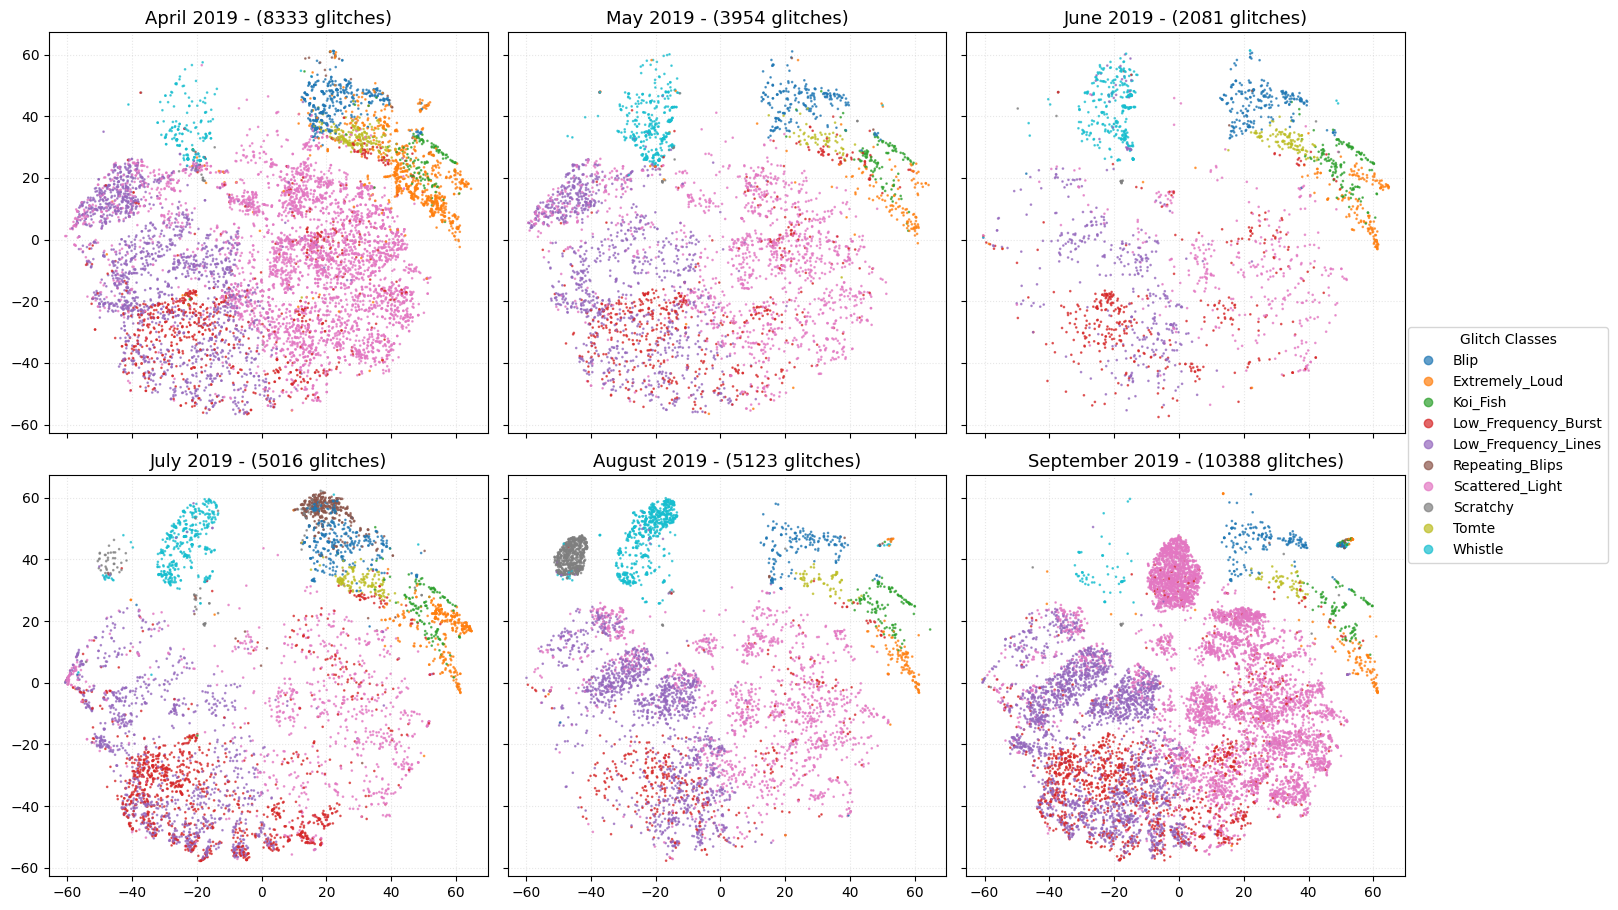

In [68]:
cmap = plt.colormaps["tab10"]
le = LabelEncoder()

labels_full = le.fit_transform(np.ravel(labs))
proj_np = proj_df.values
gps_np = np.ravel(GPSs)

x_min, x_max = proj_np[:, 0].min() - 5, proj_np[:, 0].max() + 5
y_min, y_max = proj_np[:, 1].min() - 5, proj_np[:, 1].max() + 5

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

traducao_meses = {
    'Abril': 'April', 'Maio': 'May', 'Junho': 'June', 
    'Julho': 'July', 'Agosto': 'August', 'Setembro': 'September'
}

for i, (mes_pt, (t_start, t_end)) in enumerate(o3a_intervals.items()):
    ax = axes[i]
    
    mask = (gps_np >= t_start) & (gps_np < t_end)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    if np.any(mask):
        
        sc = ax.scatter(
            proj_np[mask, 0], 
            proj_np[mask, 1], 
            s=0.8,
            c=labels_full[mask], 
            cmap=cmap, 
            vmin=0, 
            vmax=len(le.classes_)-1,
            alpha=0.7)
        
        count = np.sum(mask)
        ax.set_title(f'{traducao_meses[mes_pt]} 2019 - ({count} glitches)', fontsize=13)
    else:
        ax.set_title(f'{traducao_meses[mes_pt]} (Sem dados)', fontsize=13, color='red')

    ax.grid(True, linestyle=':', alpha=0.3)

handles, _ = sc.legend_elements()
fig.legend(handles, list(le.classes_), title="Glitch Classes", 
           loc='center right', markerscale=1.0, bbox_to_anchor=(1.08, 0.5))

plt.tight_layout(rect=[0, 0.03, 0.95, 0.95])

plt.show()

In [141]:
cmap = plt.colormaps["tab10"]
le = LabelEncoder()
labels = le.fit_transform(labs.ravel())

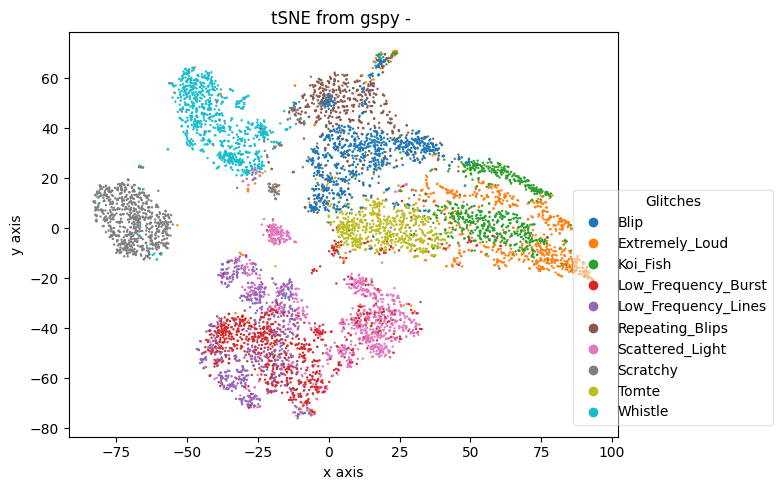

In [145]:
plt.figure(figsize=(8, 5))

sc = plt.scatter(proj_df.values[:,0], proj_df.values[:,1], s=0.5, c=labels, cmap=cmap)
plt.legend(handles=sc.legend_elements()[0], labels=list(le.classes_), title="Glitches", loc='center', framealpha=0.5, markerscale=1.0, bbox_to_anchor=(1.1, 0.32))

plt.title(f'tSNE from gspy - O')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.tight_layout()
plt.show()

In [4]:
save_path = '/home/esanches/Projetos/tSNE/Virgo/analysis/analysis_I/'

vecs = np.load(save_path + 'vecs_gspy.npy')
vecs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(35511, 1230), dtype=float32)

In [10]:
glit = pd.read_csv(path + 'gspy.csv', usecols=glitcols)

glit = glit.drop(glit[glit['label'].isin(['None_of_the_Above', 'No_Glitch'])].index)
glit = glit[glit['confidence'] >= 0.9]
top10 = glit['label'].value_counts().head(10).index
glit = glit[glit['label'].isin(top10)].copy()

glit = glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)

nofilter_glit = glit.copy()
nofilter_glit = nofilter_glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)
clustered = nofilter_glit.copy()

In [11]:
clustered

,GPStime,snr,centralFreq,confidence,label
0,1.238166e+09,12.088,211.877,1.000,Blip
1,1.238167e+09,7.867,20.195,0.998,Low_Frequency_Lines
2,1.238167e+09,8.180,65.530,1.000,Blip
3,1.238167e+09,8.306,19.370,0.965,Low_Frequency_Lines
4,1.238168e+09,12.113,357.194,1.000,Whistle
...,...,...,...,...,...
40294,1.253974e+09,10.982,36.338,1.000,Scattered_Light
40295,1.253974e+09,12.798,592.631,1.000,Scattered_Light
40296,1.253974e+09,9.501,26.590,0.996,Low_Frequency_Burst
40297,1.253975e+09,7.619,3909.822,0.991,Low_Frequency_Lines


In [ ]:
save_path = '/home/esanches/Projetos/tSNE/Virgo/teste1/'

final_vecs = np.load(save_path + 'gspy_norm_filtered.npy')

perp = 30

proj_df = func_tSNE(perp, final_vecs)
labs_df = pd.DataFrame(final_labs, columns=['label'])

In [ ]:
#save_path = '/home/esanches/Projetos/tSNE/Virgo/analysis/analysis_I'

#final_vecs = np.load(save_path + '/vecs_gspy.npy')
#final_labs = np.load(save_path + '/labels_gspy.npy')

tsne = TSNE(n_components=2, perplexity=30, metric="euclidean", random_state=0)

proj = tsne.fit_transform(final_vecs)
proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])